In [136]:
# notebooks/test_data.ipynb
# 1. Autoreload 설정
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[0]))

from data import fmri
from data.fmri import FmriVoxelData 

import numpy as np

# -----------------------------
# 1) 가짜(faked) fMRI 데이터 만들기
# -----------------------------
S, V, T = 3, 5, 10          # 사람 2명, 복셀 5개, 시간 10개
C = 3                       # 좌표는 (x,y,z) 3차원이라고 가정

data = np.random.randn(S, V, T)      # (2, 5, 10)
voxel_coord = np.random.randint(0, 100, size=(V, C))  # (5, 3)

[autoreload of cluster failed: Traceback (most recent call last):
  File "/Users/todoo/opt/anaconda3/envs/koreabank/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/todoo/opt/anaconda3/envs/koreabank/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/todoo/opt/anaconda3/envs/koreabank/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/todoo/Desktop/학교/대학원/Project/인문사회융합연구/vibe_coding/FmriHandler/cluster/__init__.py", line 1, in <module>
    from ._spectral import resolve_spectral_hyper, spectral_clust

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of similarity failed: Traceback (most recent call last):
  File "/Users/todoo/opt/anaconda3/envs/koreabank/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/todoo/opt/anaconda3/envs/koreabank/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/todoo/opt/anaconda3/envs/koreabank/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/todoo/Desktop/학교/대학원/Project/인문사회융합연구/vibe_coding/FmriHandler/similarity/__init__.py", line 1, in <module>
    from ._correlation import (
ImportError: cannot import 

In [137]:
# 1. Validation 만 수행 (아직 data 연산 안함)
raw = FmriVoxelData(data=data, voxel_coord=voxel_coord).validate()

In [138]:
# 2. 객체 생성과 동시에 내부에서 gaussian_smoothing_1d 실행
prep = raw.preprocess("gaussian_smoothing", {"fwhm_samples": 3.0, "n_jobs": -1})

In [139]:
# 3. 그 다음 단계로 전이
sim = prep.compute_similarity(
    "correlation",
    {
        "chunk_size": 50000,
        "n_jobs": 8,
        "r_min": 0.1,
        "clamp_negative": True,
    },
)

In [140]:
# 4. 클러스터링 객체 생성
clu = sim.cluster(
    cluster_method="spectral",
    cluster_hyper={
        "n_clusters": 3,         # 필수
        "remove_isolated": True,
        "kmeans_nstart": 10,
        "kmeans_itermax": 200,
        "random_state": 2026,
        "eig_solver": "auto",         # 대규모면 randomized 자동 전환
        "randomized_switch_n_nodes": 15000,
        "randomized_oversample": 20,
        "randomized_n_iter": 2,
    },
)

In [141]:
clu.label

array([[0, 1, 1, 2, 0],
       [2, 1, 0, 1, 0],
       [2, 1, 2, 1, 0]])

In [142]:
clu.label[0]

array([0, 1, 1, 2, 0])

클러스터 레이블: [0 1 1 2 0]
유니크 클러스터: [0 1 2]
클러스터 개수: 3


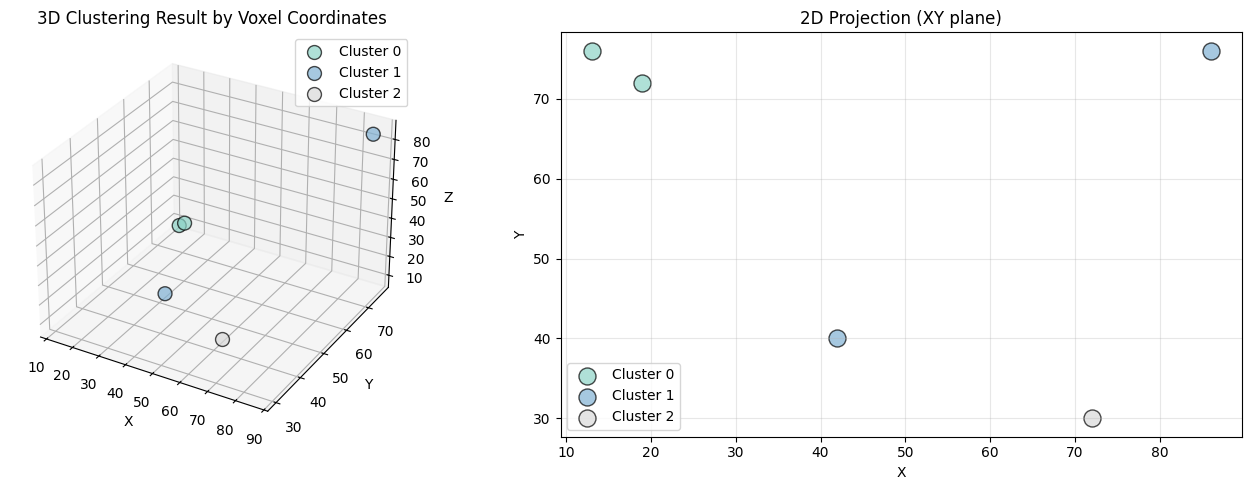

In [143]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 클러스터 시각화: 좌표 기반
coords = clu.voxel_coord  # (5, 3)
labels = clu.label[0]      # 각 복셀의 클러스터 레이블

# 고유한 클러스터 레이블 확인
unique_labels = np.unique(labels)
n_clusters = len(unique_labels[unique_labels >= 0])

print(f"클러스터 레이블: {labels}")
print(f"유니크 클러스터: {unique_labels}")
print(f"클러스터 개수: {n_clusters}")

# 3D 산점도
fig = plt.figure(figsize=(14, 5))

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters + 1))

for cluster_id in unique_labels:
    if cluster_id >= 0:
        mask = labels == cluster_id
        ax1.scatter(
            coords[mask, 0], 
            coords[mask, 1], 
            coords[mask, 2],
            c=[colors[cluster_id]],
            s=100,
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            edgecolors='black'
        )

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Clustering Result by Voxel Coordinates')
ax1.legend()

# 2D 투영 (XY 평면)
ax2 = fig.add_subplot(122)
for cluster_id in unique_labels:
    if cluster_id >= 0:
        mask = labels == cluster_id
        ax2.scatter(
            coords[mask, 0], 
            coords[mask, 1],
            c=[colors[cluster_id]],
            s=150,
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            edgecolors='black'
        )

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('2D Projection (XY plane)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

클러스터 레이블: [2 1 0 1 0]
유니크 클러스터: [0 1 2]
클러스터 개수: 3


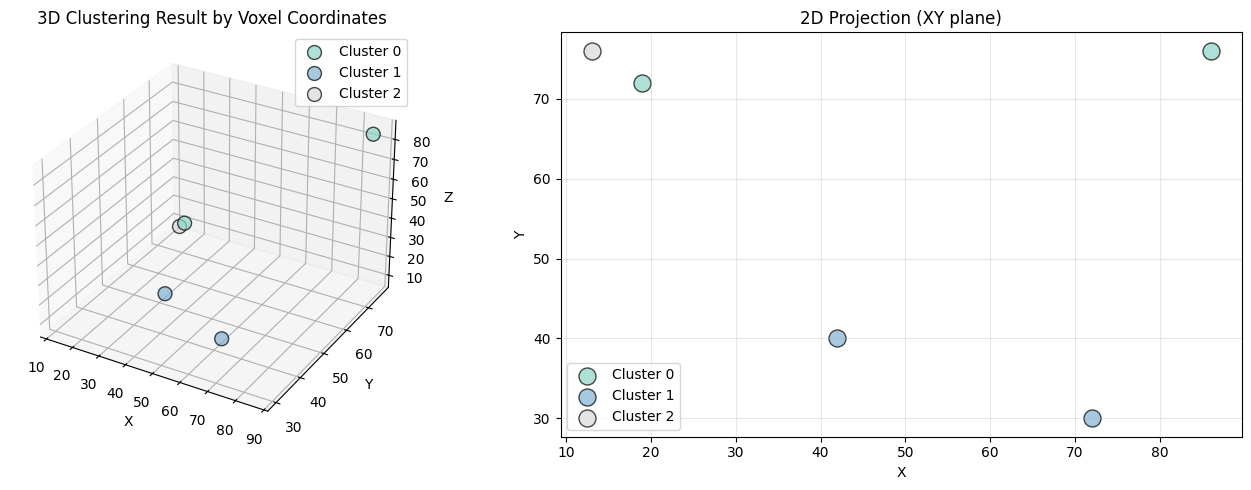

In [144]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 클러스터 시각화: 좌표 기반
coords = clu.voxel_coord  # (5, 3)
labels = clu.label[1]        # 각 복셀의 클러스터 레이블

# 고유한 클러스터 레이블 확인
unique_labels = np.unique(labels)
n_clusters = len(unique_labels[unique_labels >= 0])

print(f"클러스터 레이블: {labels}")
print(f"유니크 클러스터: {unique_labels}")
print(f"클러스터 개수: {n_clusters}")

# 3D 산점도
fig = plt.figure(figsize=(14, 5))

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters + 1))

for cluster_id in unique_labels:
    if cluster_id >= 0:
        mask = labels == cluster_id
        ax1.scatter(
            coords[mask, 0], 
            coords[mask, 1], 
            coords[mask, 2],
            c=[colors[cluster_id]],
            s=100,
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            edgecolors='black'
        )

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Clustering Result by Voxel Coordinates')
ax1.legend()

# 2D 투영 (XY 평면)
ax2 = fig.add_subplot(122)
for cluster_id in unique_labels:
    if cluster_id >= 0:
        mask = labels == cluster_id
        ax2.scatter(
            coords[mask, 0], 
            coords[mask, 1],
            c=[colors[cluster_id]],
            s=150,
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            edgecolors='black'
        )

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('2D Projection (XY plane)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()